In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [18]:
TICKERS = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS']
START, END = '2022-01-01', '2026-06-26'
raw  = yf.download(TICKERS, start=START, end=END)
data = raw['Close']
data

[*********************100%***********************]  4 of 4 completed


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2022-01-03,711.042419,1668.151611,1088.746704,3341.055664
2022-01-04,715.206604,1668.766724,1113.317383,3399.690674
2022-01-05,732.191345,1620.878174,1118.526123,3378.862305
2022-01-06,720.447083,1597.285400,1094.476074,3332.042480
2022-01-07,725.500427,1594.209839,1103.308105,3372.342285
...,...,...,...,...
2026-06-19,779.799988,1051.400024,1309.500000,2125.000000
2026-06-22,786.400024,1065.400024,1326.500000,2127.800049
2026-06-23,774.650024,1029.300049,1309.500000,2059.600098


In [19]:
NAMES   = {'RELIANCE.NS': 'Reliance', 'TCS.NS': 'TCS',
           'HDFCBANK.NS': 'HDFC Bank', 'INFY.NS': 'Infosys'}
data.columns = [NAMES[f] for f in data.columns]
data.head()

,HDFC Bank,Infosys,Reliance,TCS
Date,,,,
2022-01-03,711.042419,1668.151611,1088.746704,3341.055664
2022-01-04,715.206604,1668.766724,1113.317383,3399.690674
2022-01-05,732.191345,1620.878174,1118.526123,3378.862305
2022-01-06,720.447083,1597.285400,1094.476074,3332.042480
2022-01-07,725.500427,1594.209839,1103.308105,3372.342285


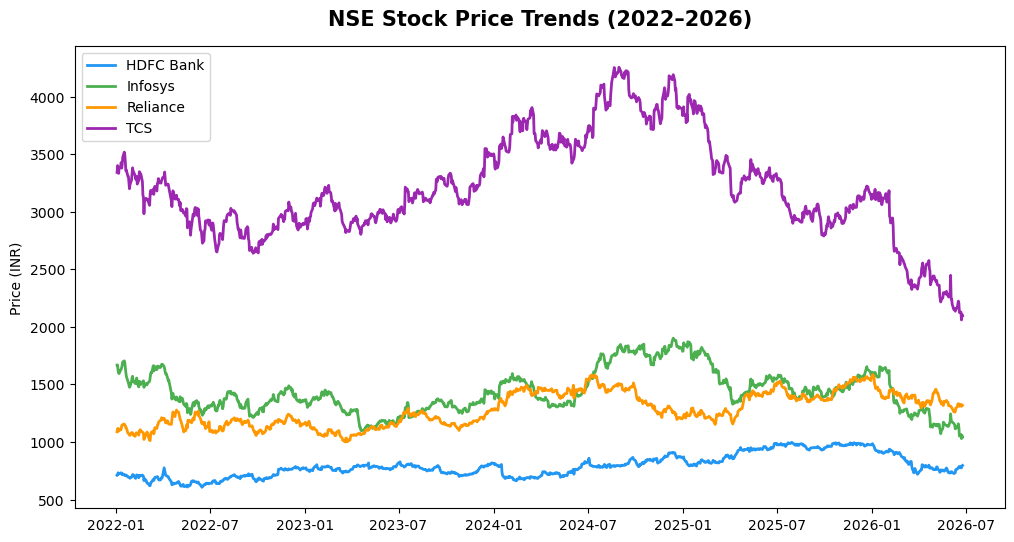

In [20]:
COLORS  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(data.columns, COLORS):
    ax.plot(data.index, data[col], label=col, color=color, linewidth=2)
ax.set_title('NSE Stock Price Trends (2022–2026)', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Price (INR)')
ax.set_xlabel('')
ax.legend(loc='upper left')

In [21]:
normalized_data = data / data.iloc[0] * 100
normalized_data

,HDFC Bank,Infosys,Reliance,TCS
Date,,,,
2022-01-03,100.000000,100.000000,100.000000,100.000000
2022-01-04,100.585645,100.036874,102.256786,101.754985
2022-01-05,102.974355,97.166119,102.735202,101.131578
2022-01-06,101.322659,95.751812,100.526235,99.730229
2022-01-07,102.033354,95.567443,101.337446,100.936429
...,...,...,...,...
2026-06-19,109.669967,63.027846,120.275909,63.602652
2026-06-22,110.598187,63.867098,121.837338,63.686459
2026-06-23,108.945684,61.703028,120.275909,61.645190


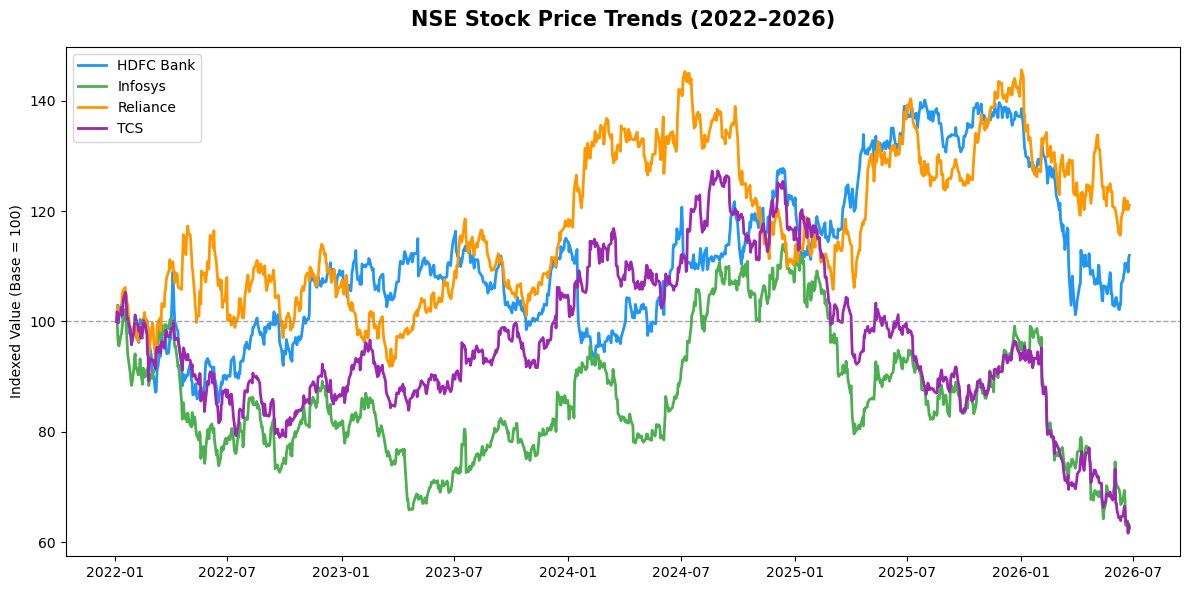

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
for col, color in zip(normalized_data.columns, COLORS):
    ax.plot(normalized_data.index, normalized_data[col], label=col, color=color, linewidth=2)
ax.set_title('NSE Stock Price Trends (2022–2026)', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Indexed Value (Base = 100)')
ax.set_xlabel('')
ax.legend(loc='upper left')
ax.axhline(y=100, linestyle='--', color='gray', linewidth=1, alpha=0.7)
plt.tight_layout()

Reliance was the only stock to deliver consistent positive returns over the 2022–2026 period, peaking at ~40% gain and currently holding at ~21%. HDFC Bank recovered strongly after a sharp dip during its 2023 merger period, ending at ~12% gain.
TCS and Infosys — despite being India's top IT companies, both lost over 35% of their value. This reflects the global IT sector slowdown post-2022 as US tech spending contracted.
Insight: Company quality alone doesn't guarantee returns. Sector timing and macroeconomic conditions played a bigger role here than individual company performance.

In [23]:
returns = data.pct_change().dropna()
returns.head()

,HDFC Bank,Infosys,Reliance,TCS
Date,,,,
2022-01-04,0.005856,0.000369,0.022568,0.017550
2022-01-05,0.023748,-0.028697,0.004679,-0.006127
2022-01-06,-0.016040,-0.014556,-0.021502,-0.013857
2022-01-07,0.007014,-0.001925,0.008070,0.012095
2022-01-10,0.005546,0.020090,0.000821,0.006838


In [24]:
ann_vol = (returns.std() * (252 ** 0.5) * 100).round(2)
ann_vol.head()

HDFC Bank    21.11
Infosys      25.87
Reliance     22.10
TCS          22.05
dtype: float64

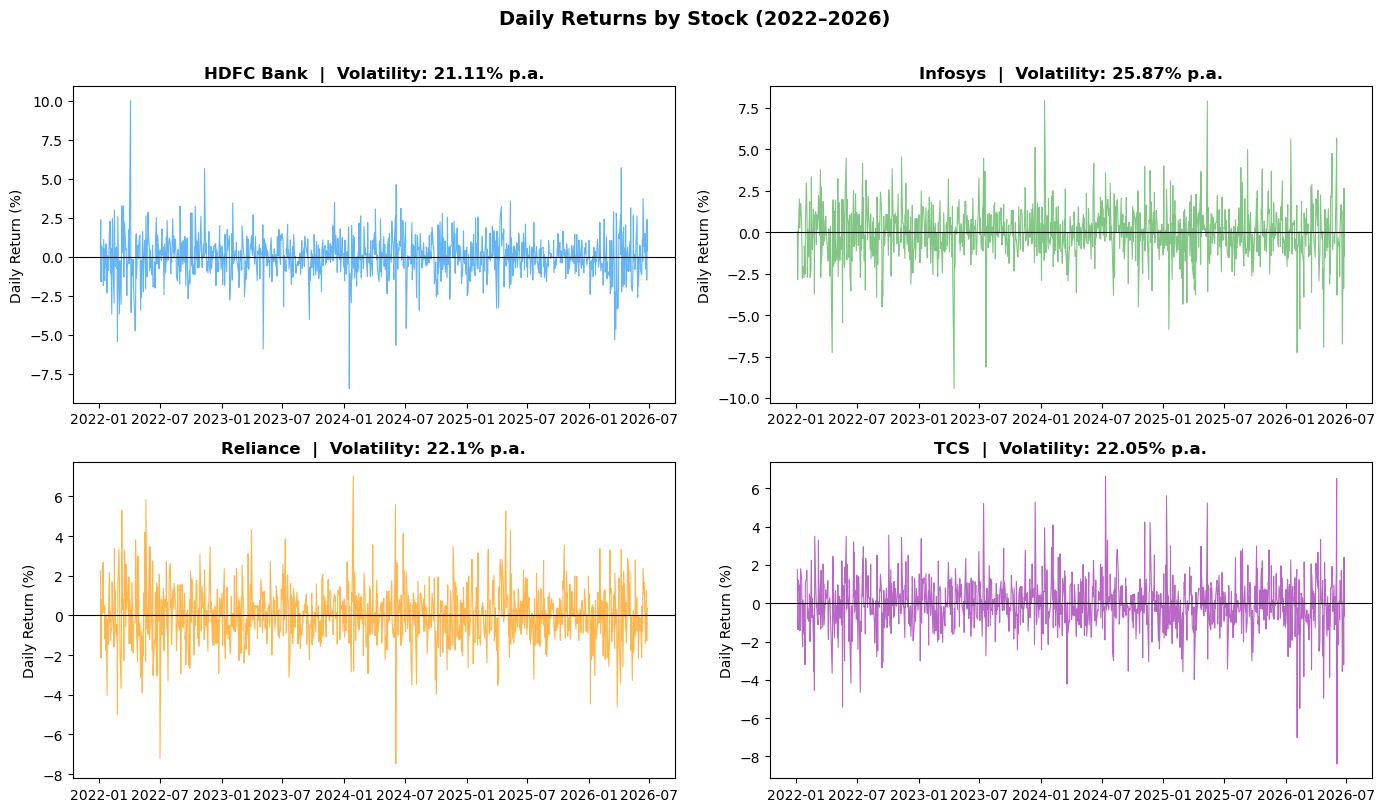

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for i, (col, color) in enumerate(zip(data.columns, COLORS)):
    axes[i].plot(returns.index, returns[col] * 100, color=color, alpha=0.7, linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{col}  |  Volatility: {ann_vol[col]}% p.a.', fontweight='bold')
    axes[i].set_ylabel('Daily Return (%)')
fig.suptitle('Daily Returns by Stock (2022–2026)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

All 4 stocks show similar annualised volatility (21–26%), yet their return outcomes were drastically different — Reliance gained 21% while TCS lost 37%. This proves volatility alone is a poor predictor of returns. Notable observation: daily return spikes increased across all stocks post-2024, suggesting rising market uncertainty. HDFC Bank showed the most contained daily swings, confirming its defensive characteristics